In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tell Python where your data files are
import os
os.chdir('../data')

# Load all Olist datasets
customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')

print("All files loaded successfully!")

All files loaded successfully!


In [3]:
# See the size of each dataset (rows, columns)
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Order Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Products: (32951, 9)
Sellers: (3095, 4)


In [4]:
# Preview the orders table - see first 5 rows
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
# Preview the orders table - see first 5 rows
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
# Check missing values properly
print("=== Missing Values in Orders ===")
print(orders.isnull().sum())
print("\n=== Order Status Breakdown ===")
print(orders['order_status'].value_counts())

=== Missing Values in Orders ===
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

=== Order Status Breakdown ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [7]:
# Convert date columns to proper datetime format
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])

# Calculate delivery delay (negative = early, positive = late)
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()
delivered_orders['delivery_delay_days'] = (
    delivered_orders['order_delivered_customer_date'] - 
    delivered_orders['order_estimated_delivery_date']
).dt.days

print("Data cleaned successfully!")
print(f"\nTotal delivered orders: {len(delivered_orders):,}")
print(f"Late deliveries: {(delivered_orders['delivery_delay_days'] > 0).sum():,}")
print(f"On-time deliveries: {(delivered_orders['delivery_delay_days'] <= 0).sum():,}")

Data cleaned successfully!

Total delivered orders: 96,478
Late deliveries: 6,534
On-time deliveries: 89,936


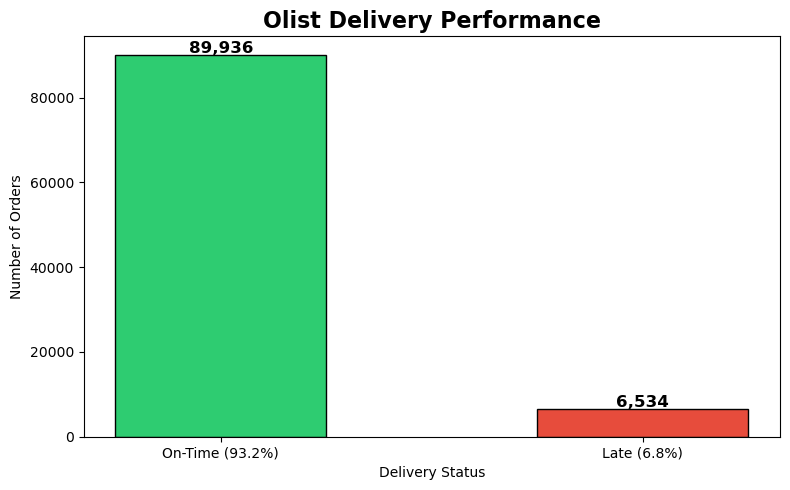

Chart saved!


In [9]:
# Chart 1 - On-time vs Late Deliveries (fixed)
plt.figure(figsize=(8, 5))
labels = ['On-Time (93.2%)', 'Late (6.8%)']
values = [89936, 6534]
colors = ['#2ecc71', '#e74c3c']

plt.bar(labels, values, color=colors, edgecolor='black', width=0.5)
plt.title('Olist Delivery Performance', fontsize=16, fontweight='bold')
plt.ylabel('Number of Orders')
plt.xlabel('Delivery Status')

for i, v in enumerate(values):
    plt.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('delivery_performance.png', dpi=150)
plt.show()
print("Chart saved!")

In [10]:
# How many days late on average?
print(f"Average delay for late orders: {delivered_orders[delivered_orders['delivery_delay_days'] > 0]['delivery_delay_days'].mean():.1f} days")
print(f"Worst delay: {delivered_orders['delivery_delay_days'].max()} days")
print(f"Most early delivery: {delivered_orders['delivery_delay_days'].min()} days")

Average delay for late orders: 10.6 days
Worst delay: 188.0 days
Most early delivery: -147.0 days


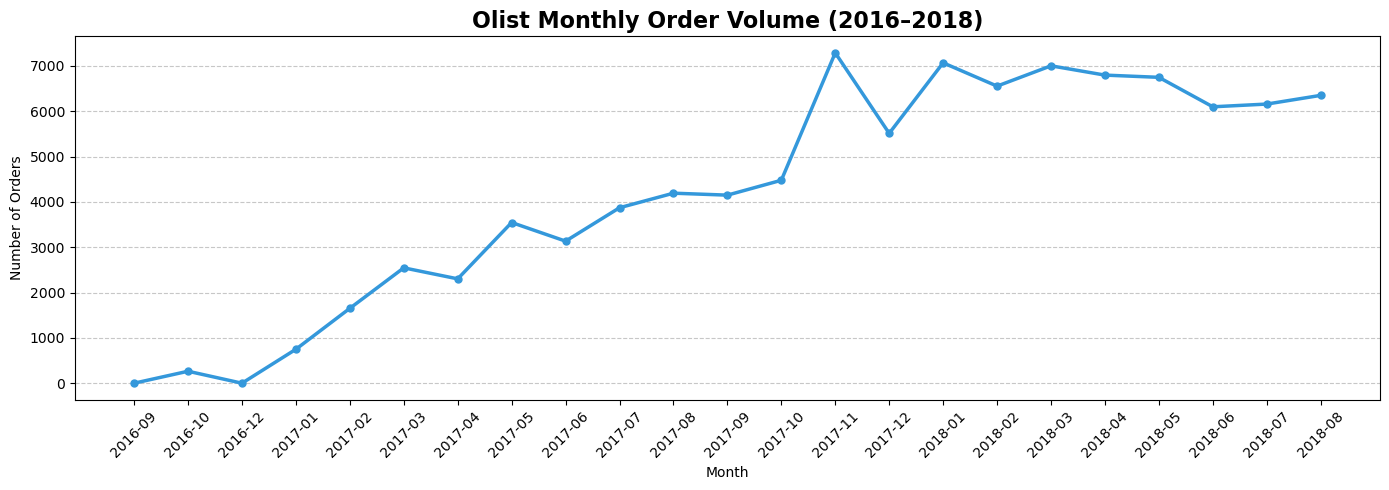

Chart saved!


In [11]:
# Extract month and year from order date
delivered_orders['order_month'] = delivered_orders['order_purchase_timestamp'].dt.to_period('M')

# Count orders per month
monthly_orders = delivered_orders.groupby('order_month').size().reset_index(name='order_count')

# Plot
plt.figure(figsize=(14, 5))
plt.plot(monthly_orders['order_month'].astype(str), 
         monthly_orders['order_count'], 
         marker='o', color='#3498db', linewidth=2.5, markersize=5)

plt.title('Olist Monthly Order Volume (2016–2018)', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('monthly_orders.png', dpi=150)
plt.show()
print("Chart saved!")

In [12]:
# Merge orders with payments
revenue_data = delivered_orders.merge(payments, on='order_id', how='left')

# Total revenue
total_revenue = revenue_data['payment_value'].sum()
avg_order_value = revenue_data['payment_value'].mean()

print(f"Total Revenue: R$ {total_revenue:,.2f}")
print(f"Average Order Value: R$ {avg_order_value:,.2f}")
print(f"\nPayment Type Breakdown:")
print(revenue_data['payment_type'].value_counts())

Total Revenue: R$ 15,422,461.77
Average Order Value: R$ 153.07

Payment Type Breakdown:
payment_type
credit_card    74586
boleto         19191
voucher         5493
debit_card      1486
Name: count, dtype: int64


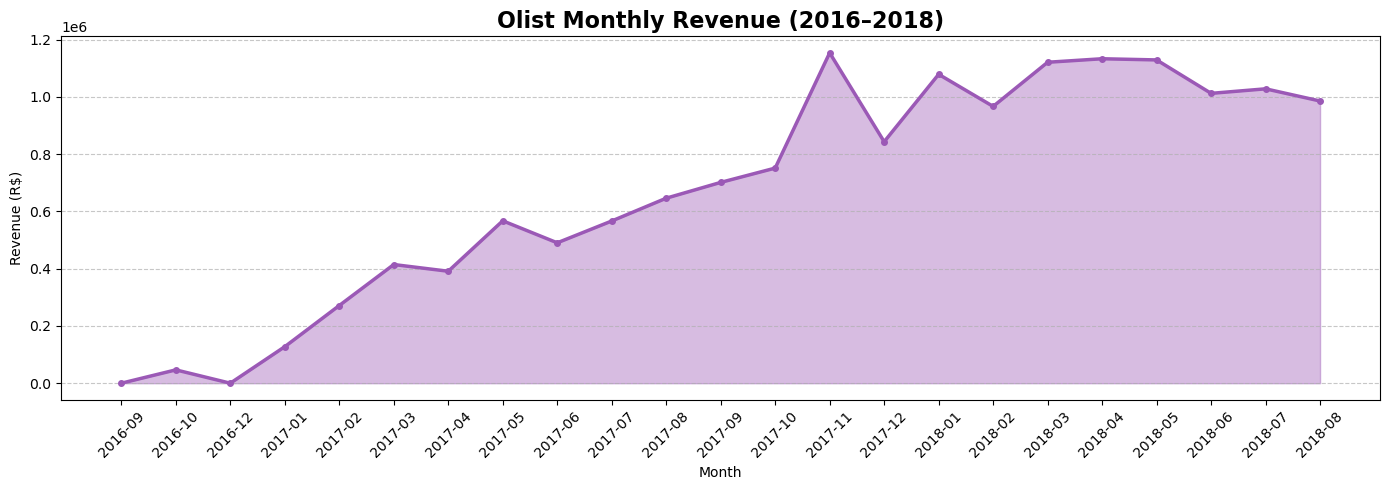

Chart saved!


In [13]:
# Monthly revenue trend
revenue_data['order_month'] = revenue_data['order_purchase_timestamp'].dt.to_period('M')
monthly_revenue = revenue_data.groupby('order_month')['payment_value'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.fill_between(monthly_revenue['order_month'].astype(str), 
                 monthly_revenue['payment_value'], 
                 alpha=0.4, color='#9b59b6')
plt.plot(monthly_revenue['order_month'].astype(str), 
         monthly_revenue['payment_value'], 
         color='#9b59b6', linewidth=2.5, marker='o', markersize=4)

plt.title('Olist Monthly Revenue (2016–2018)', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150)
plt.show()
print("Chart saved!")

In [14]:
# Merge reviews with delivered orders
satisfaction_data = delivered_orders.merge(reviews[['order_id', 'review_score']], 
                                            on='order_id', how='left')

# Average review score overall
print(f"Overall Average Review Score: {satisfaction_data['review_score'].mean():.2f} / 5")
print(f"\nReview Score Distribution:")
print(satisfaction_data['review_score'].value_counts().sort_index())

Overall Average Review Score: 4.16 / 5

Review Score Distribution:
review_score
1.0     9406
2.0     2941
3.0     7961
4.0    18987
5.0    57066
Name: count, dtype: int64


Average Score - On-Time Deliveries: 4.29 / 5
Average Score - Late Deliveries: 2.27 / 5
Score Drop Due to Late Delivery: 2.02 points


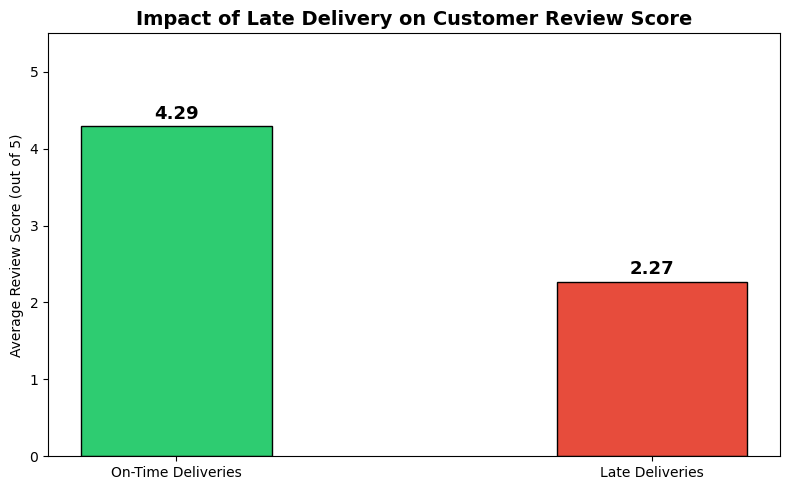

Chart saved!


In [15]:
# Average review score: on-time vs late
on_time_score = satisfaction_data[satisfaction_data['delivery_delay_days'] <= 0]['review_score'].mean()
late_score = satisfaction_data[satisfaction_data['delivery_delay_days'] > 0]['review_score'].mean()

print(f"Average Score - On-Time Deliveries: {on_time_score:.2f} / 5")
print(f"Average Score - Late Deliveries: {late_score:.2f} / 5")
print(f"Score Drop Due to Late Delivery: {on_time_score - late_score:.2f} points")

# Visualize
plt.figure(figsize=(8, 5))
categories = ['On-Time Deliveries', 'Late Deliveries']
scores = [on_time_score, late_score]
colors = ['#2ecc71', '#e74c3c']

bars = plt.bar(categories, scores, color=colors, edgecolor='black', width=0.4)
plt.title('Impact of Late Delivery on Customer Review Score', fontsize=14, fontweight='bold')
plt.ylabel('Average Review Score (out of 5)')
plt.ylim(0, 5.5)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{score:.2f}', ha='center', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('satisfaction_vs_delivery.png', dpi=150)
plt.show()
print("Chart saved!")

In [16]:
# Load category translation
category_translation = pd.read_csv('product_category_name_translation.csv')

# Merge products with categories
products_translated = products.merge(category_translation, 
                                      on='product_category_name', how='left')

# Merge with order items
category_sales = order_items.merge(products_translated[['product_id', 
                                   'product_category_name_english']], 
                                    on='product_id', how='left')

# Top 10 categories by number of orders
top_categories = category_sales['product_category_name_english'].value_counts().head(10)
print("Top 10 Product Categories:")
print(top_categories)

Top 10 Product Categories:
product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
Name: count, dtype: int64


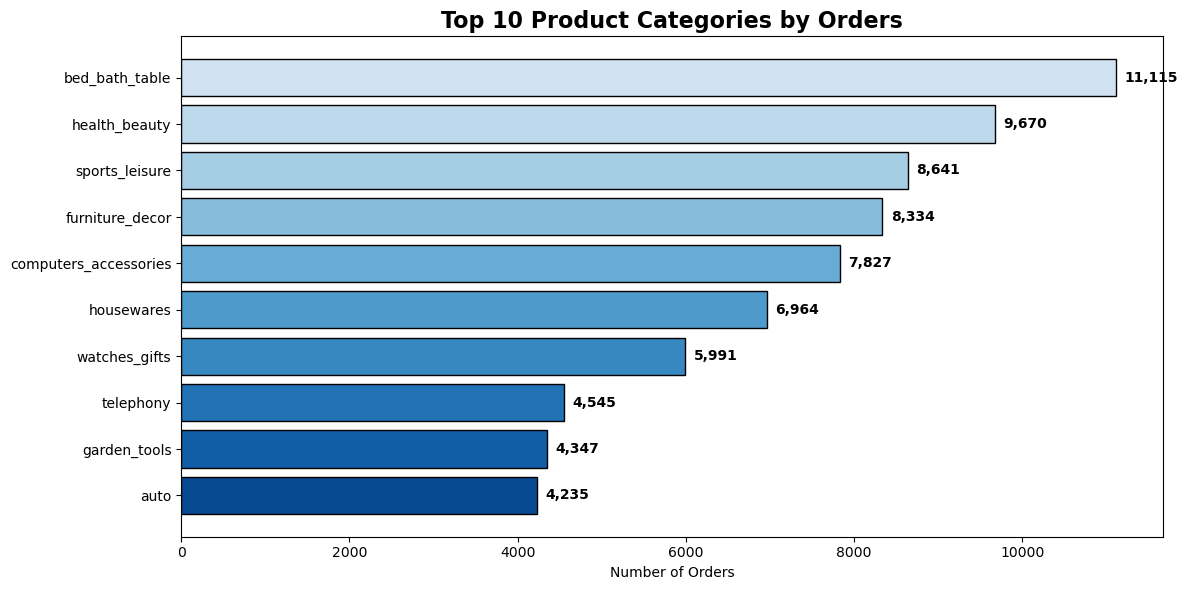

Chart saved!


In [17]:
plt.figure(figsize=(12, 6))
colors = plt.cm.Blues(range(50, 255, 20))[:10][::-1]

bars = plt.barh(top_categories.index[::-1], 
                top_categories.values[::-1], 
                color=colors, edgecolor='black')

plt.title('Top 10 Product Categories by Orders', fontsize=16, fontweight='bold')
plt.xlabel('Number of Orders')

for bar, val in zip(bars, top_categories.values[::-1]):
    plt.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2, 
             f'{val:,}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('top_categories.png', dpi=150)
plt.show()
print("Chart saved!")

In [19]:
# Merge seller data with order items and payments
seller_performance = order_items.merge(payments[['order_id', 'payment_value']], 
                                        on='order_id', how='left')
seller_performance = seller_performance.merge(sellers, on='seller_id', how='left')

# Top 10 sellers by revenue
top_sellers = seller_performance.groupby('seller_id')['payment_value'].sum().sort_values(ascending=False).head(10)

# Seller stats
total_sellers = sellers['seller_id'].nunique()
avg_revenue_per_seller = seller_performance.groupby('seller_id')['payment_value'].sum().mean()
top10_revenue = top_sellers.sum()
total_revenue_sellers = seller_performance['payment_value'].sum()

print(f"Total Sellers: {total_sellers:,}")
print(f"Average Revenue per Seller: R$ {avg_revenue_per_seller:,.2f}")
print(f"Top 10 Sellers Revenue: R$ {top10_revenue:,.2f}")
print(f"Top 10 Sellers % of Total Revenue: {(top10_revenue/total_revenue_sellers)*100:.1f}%")

Total Sellers: 3,095
Average Revenue per Seller: R$ 6,561.59
Top 10 Sellers Revenue: R$ 2,856,145.90
Top 10 Sellers % of Total Revenue: 14.1%


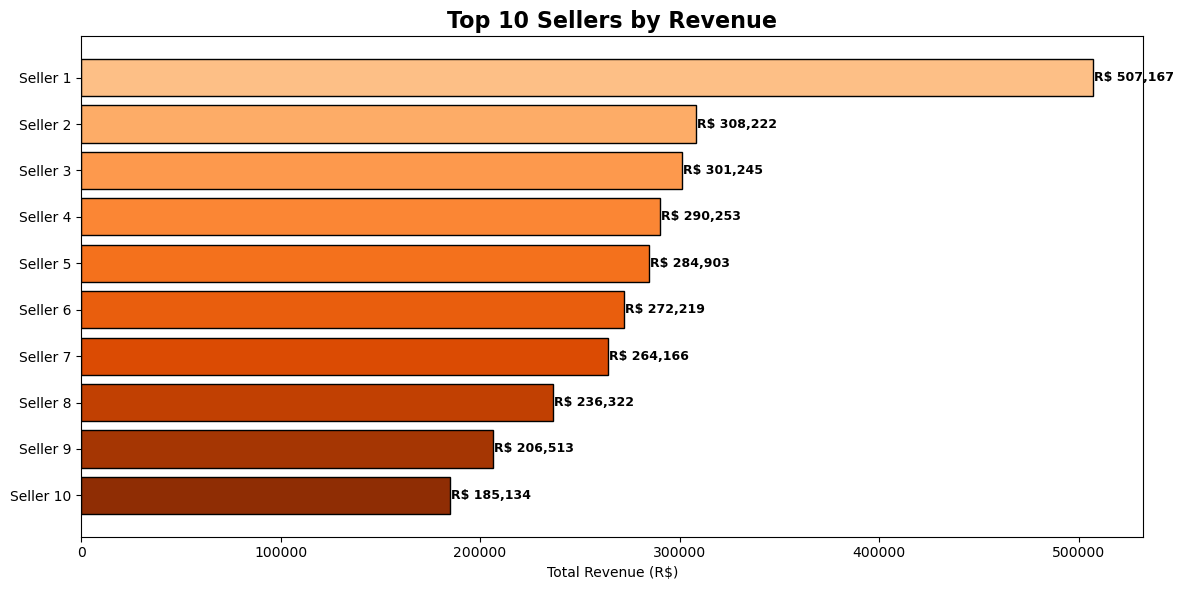

Chart saved!


In [20]:
plt.figure(figsize=(12, 6))
seller_labels = [f"Seller {i+1}" for i in range(10)]
colors = plt.cm.Oranges(range(80, 255, 18))[:10][::-1]

bars = plt.barh(seller_labels[::-1], 
                top_sellers.values[::-1], 
                color=colors, edgecolor='black')

plt.title('Top 10 Sellers by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue (R$)')

for bar, val in zip(bars, top_sellers.values[::-1]):
    plt.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             f'R$ {val:,.0f}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('top_sellers.png', dpi=150)
plt.show()
print("Chart saved!")

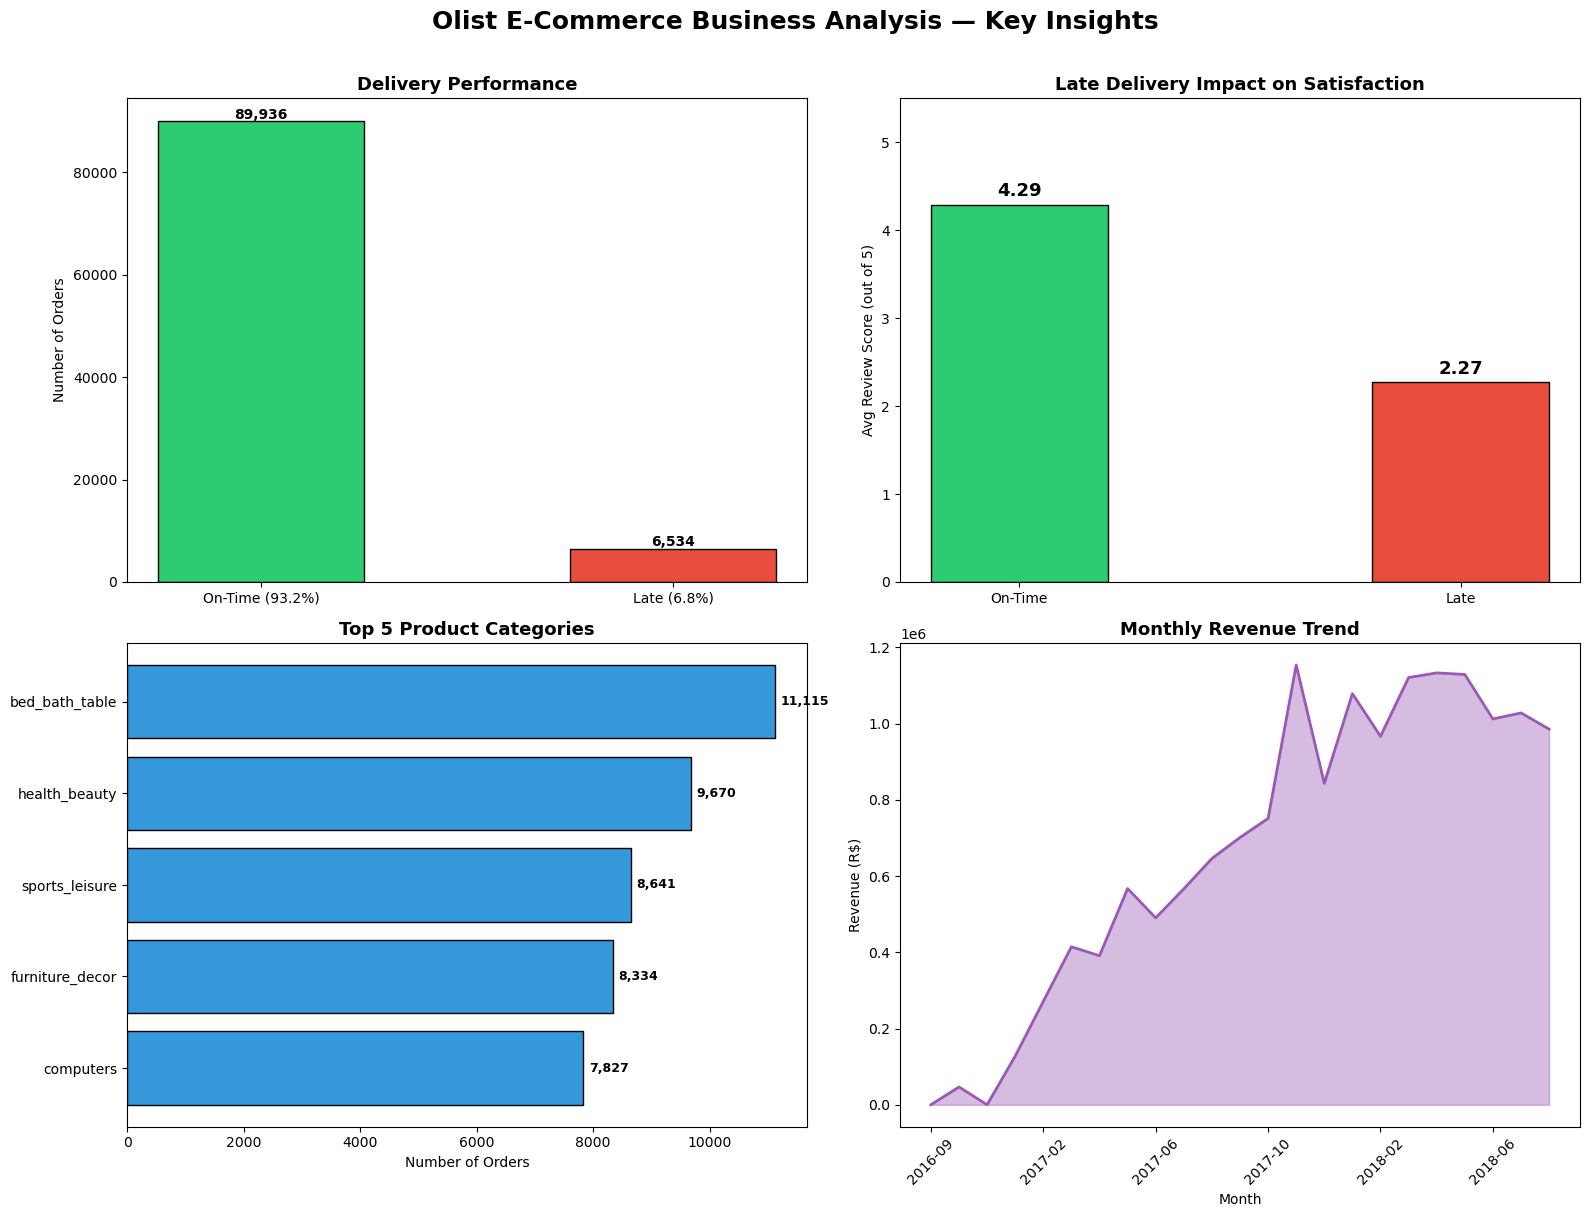

Final dashboard saved!


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Olist E-Commerce Business Analysis — Key Insights', 
             fontsize=18, fontweight='bold', y=1.01)

# Chart 1 - Delivery Performance
ax1 = axes[0, 0]
ax1.bar(['On-Time (93.2%)', 'Late (6.8%)'], [89936, 6534], 
        color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
ax1.set_title('Delivery Performance', fontweight='bold', fontsize=13)
ax1.set_ylabel('Number of Orders')
for i, v in enumerate([89936, 6534]):
    ax1.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Chart 2 - Satisfaction vs Delivery
ax2 = axes[0, 1]
ax2.bar(['On-Time', 'Late'], [4.29, 2.27], 
        color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.4)
ax2.set_title('Late Delivery Impact on Satisfaction', fontweight='bold', fontsize=13)
ax2.set_ylabel('Avg Review Score (out of 5)')
ax2.set_ylim(0, 5.5)
for i, v in enumerate([4.29, 2.27]):
    ax2.text(i, v + 0.1, f'{v}', ha='center', fontweight='bold', fontsize=13)

# Chart 3 - Top 5 Categories
ax3 = axes[1, 0]
top5_cats = ['bed_bath_table', 'health_beauty', 'sports_leisure', 
             'furniture_decor', 'computers']
top5_vals = [11115, 9670, 8641, 8334, 7827]
ax3.barh(top5_cats[::-1], top5_vals[::-1], 
         color='#3498db', edgecolor='black')
ax3.set_title('Top 5 Product Categories', fontweight='bold', fontsize=13)
ax3.set_xlabel('Number of Orders')
for i, v in enumerate(top5_vals[::-1]):
    ax3.text(v + 100, i, f'{v:,}', va='center', fontweight='bold', fontsize=9)

# Chart 4 - Monthly Revenue
ax4 = axes[1, 1]
ax4.fill_between(monthly_revenue['order_month'].astype(str), 
                 monthly_revenue['payment_value'], alpha=0.4, color='#9b59b6')
ax4.plot(monthly_revenue['order_month'].astype(str), 
         monthly_revenue['payment_value'], color='#9b59b6', linewidth=2)
ax4.set_title('Monthly Revenue Trend', fontweight='bold', fontsize=13)
ax4.set_ylabel('Revenue (R$)')
ax4.set_xlabel('Month')
ax4.tick_params(axis='x', rotation=45)
# Show only every 4th label
labels = monthly_revenue['order_month'].astype(str).tolist()
ax4.set_xticks(range(0, len(labels), 4))
ax4.set_xticklabels(labels[::4], rotation=45)

plt.tight_layout()
plt.savefig('final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Final dashboard saved!")